In [1]:
import pandas as pd
data=pd.read_csv("student_scores.csv")
print(data.head(10))


     name  hours  score gender grades class
0   Aarav      8     76      M      A    9A
1    Riya      5     62      F      B    9B
2   Kabir     10     88      M      A   10A
3    Sana      4     55      F      C    9A
4  Vivaan      7     72      M      B   10B
5  Ishita      6     64      F      B    9C
6   Rohan      3     48      M      D    9B
7   Meera      9     90      F      A   11A
8  Aditya      2     38      M      F    9C
9   Kavya     11     93      F      A   12A


In [2]:
print('Colums:',data.columns.tolist())


Colums: ['name', 'hours', 'score', 'gender', 'grades', 'class']


In [3]:
print("\nInfo")
print(data.info())


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    92 non-null     object
 1   hours   92 non-null     int64 
 2   score   92 non-null     int64 
 3   gender  92 non-null     object
 4   grades  92 non-null     object
 5   class   92 non-null     object
dtypes: int64(2), object(4)
memory usage: 4.4+ KB
None


In [4]:
print("Describe:")
display(data.describe())

Describe:


,hours,score
count,92.000000,92.000000
mean,6.510870,68.836957
std,2.265336,15.692286
min,2.000000,35.000000
25%,5.000000,57.000000
50%,7.000000,70.000000
75%,8.000000,82.000000
max,11.000000,94.000000


In [5]:
print(data.isnull().sum())

name      0
hours     0
score     0
gender    0
grades    0
class     0
dtype: int64


In [6]:
print("Data Consistency:")
print(data.dtypes)

Data Consistency:
name      object
hours      int64
score      int64
gender    object
grades    object
class     object
dtype: object


In [7]:
print("\nDataset Bias")
print(data['gender'].value_counts(normalize=True))
print(data['grades'].value_counts(normalize=True))
print(data['class'].value_counts(normalize=True))


Dataset Bias
gender
F    0.51087
M    0.48913
Name: proportion, dtype: float64
grades
B    0.358696
A    0.326087
C    0.195652
D    0.086957
F    0.032609
Name: proportion, dtype: float64
class
9A     0.141304
10A    0.119565
9B     0.108696
9C     0.108696
10B    0.086957
11A    0.086957
10C    0.076087
12A    0.065217
12B    0.065217
11B    0.054348
12C    0.054348
11C    0.032609
Name: proportion, dtype: float64


In [8]:
categorical=data.select_dtypes(include='object').columns
numerical=data.select_dtypes(exclude='object').columns

print("Categorical Features:",list(categorical))
print("Numerical Features:",list(numerical))

Categorical Features: ['name', 'gender', 'grades', 'class']
Numerical Features: ['hours', 'score']


In [42]:
X=data[['hours']]
X


,hours
0,8
1,5
2,10
3,4
4,7
...,...
87,4
88,10
89,7
90,5


In [43]:
y=data['score']
y

0     76
1     62
2     88
3     55
4     72
      ..
87    52
88    88
89    73
90    57
91    81
Name: score, Length: 92, dtype: int64

In [44]:
import seaborn as sns

In [45]:
import matplotlib.pyplot as plt

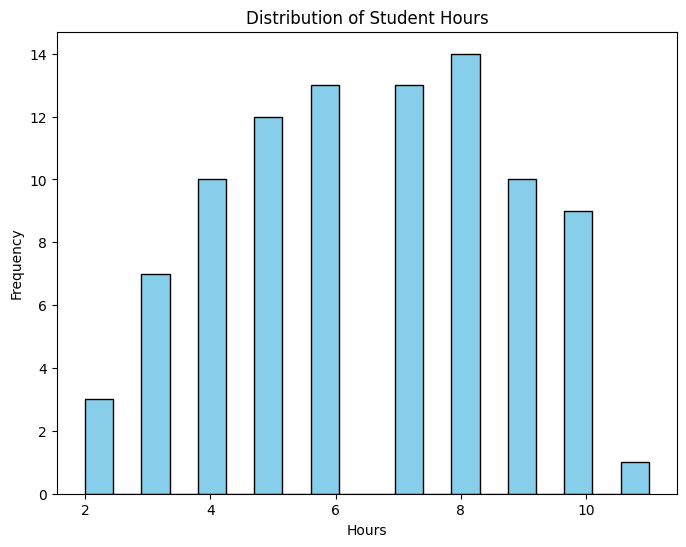

In [46]:
plt.figure(figsize=(8,6))
plt.hist(X,bins=20,color='skyblue',edgecolor='black')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Student Hours')
plt.show()

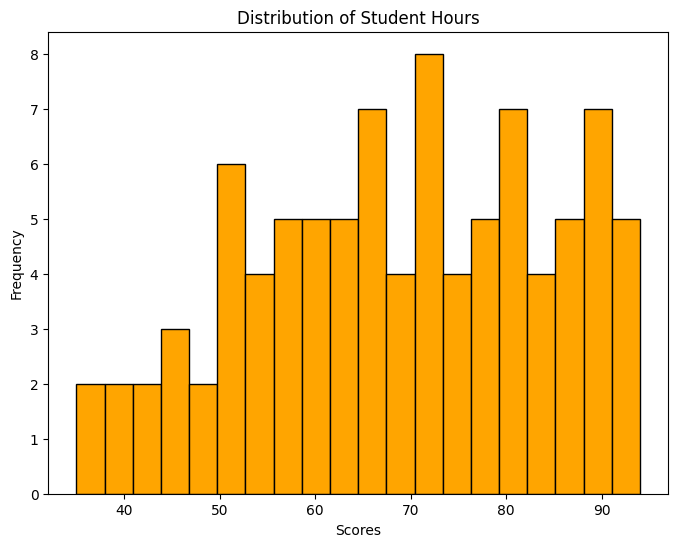

In [47]:
plt.figure(figsize=(8,6))
plt.hist(y,bins=20,color='orange',edgecolor='black')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Distribution of Student Hours')
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=40
    )

In [49]:
from sklearn.linear_model import LinearRegression

# X_train = X_train.reshape(-1, 1)
# X_test = X_test.reshape(-1, 1)


In [50]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
print("Model Coefficient(Slope):",model.coef_[0])
print("Model Intercept:",model.intercept_)

Model Coefficient(Slope): 6.964922090509209
Model Intercept: 23.7723477223589


In [54]:
y_pred = model.predict(X_test)
pred_data = { 'y_prediction ': y_pred.round(2),
              'y_test': y_test.reset_index(drop = True)}

prediction_table = pd.DataFrame(pred_data)
print("prediction table : ")
print(prediction_table)

user_input = pd.DataFrame([[10]],columns = ['hours'])
print(model.predict(user_input))


prediction table : 
    y_prediction   y_test
0           72.53      74
1           51.63      50
2           93.42      88
3           79.49      77
4           58.60      57
5           65.56      63
6           86.46      85
7           51.63      53
8           79.49      78
9           93.42      89
10         100.39      93
11          44.67      42
12          72.53      70
13          51.63      54
14          79.49      81
15          58.60      55
16          79.49      82
17          79.49      83
18          72.53      71
[93.42156863]


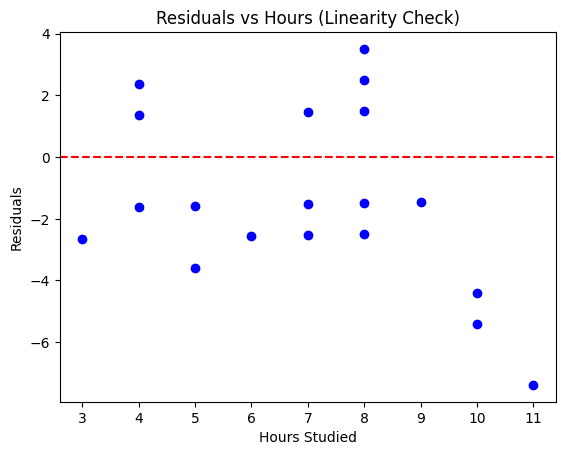

In [62]:

residuals = y_test - y_pred



plt.scatter(X_test, residuals, color='blue')


plt.axhline(y=0, color='red', linestyle='--')


plt.xlabel("Hours Studied")
plt.ylabel("Residuals")
plt.title("Residuals vs Hours (Linearity Check)")
plt.show()



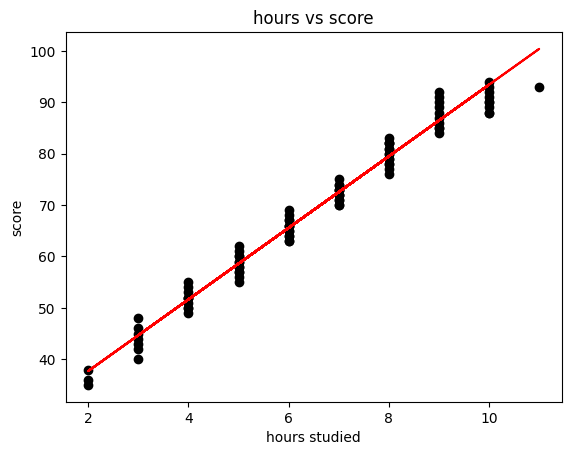

In [60]:
import matplotlib.pyplot as plt
plt.scatter(X,y,color ='black')
plt.plot(X,model.predict(X),color='red')
plt.title('hours vs score')
plt.xlabel('hours studied')
plt.ylabel('score')
plt.show()

In [63]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.3f}")



MSE : 9.74
RMSE : 3.12
R2 : 0.956


In [64]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [66]:
X=np.array([[1],[2],[3],[4],[5]])
y=np.array([12,18,25,27,35])

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

gd_model=SGDRegressor(
    learning_rate="constant",
    eta0=0.1,
    max_iter=1000,
    tol=1e-3,
    random_state=42

)

gd_model.fit(X_scaled,y)

y_pred=gd_model.predict(X_scaled)

print("Model Parameters:")

print("Slope (m):", gd_model.coef_[0])
print("Intercept (c):", gd_model.intercept_[0])

print("\nEvaluation Metrics:")
print("MSE:", mean_squared_error(y, y_pred))
print("MAE :", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R2 :", r2_score(y, y_pred))

x_new = np.array([[6]])
x_new_scaled = scaler.transform(x_new)
print("\nPrediction for 6 study hours:", gd_model.predict(x_new_scaled)[0])
    

Model Parameters:
Slope (m): 7.8410451911974155
Intercept (c): 23.417468861833534

Evaluation Metrics:
MSE: 1.3442578732449164
MAE : 0.8987237371189473
RMSE: 1.1594213527639192
R2 : 0.9782623241713306

Prediction for 6 study hours: 40.05083754069112
